In [15]:
import pandas as pd
from matplotlib import pyplot as plt

In [59]:
import seaborn as sns

In [11]:
df = pd.read_csv('C:/Users/HUAWEI/Downloads/bank.csv', sep=',')

In [12]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [70]:
bins = [18,29,35,47,60,100]
labels =['18-29','30-35','36-47','48-60','61-100']

In [71]:
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

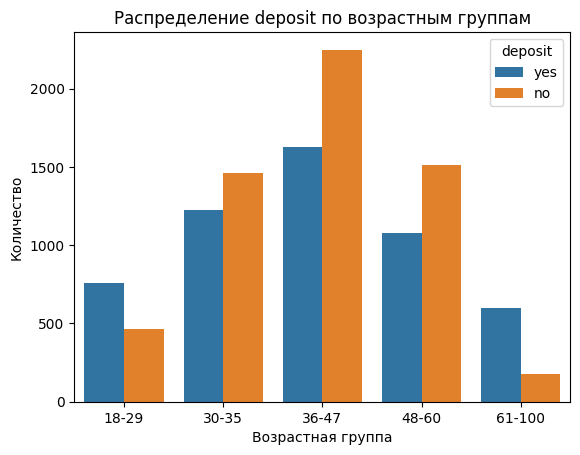

In [72]:
sns.countplot(data=df, x='age_group', hue='deposit', order=labels)
plt.title('Распределение deposit по возрастным группам')
plt.xlabel('Возрастная группа')
plt.ylabel('Количество')
plt.legend(title='deposit')
plt.show()

Наибольшая склонность к открытию депозитов наблюдается в двух возрастных категориях: 18–29 лет и 61–100 лет. Вероятное объяснение: для первых — отсутствие крупных обязательств и мотивация к накоплению; для вторых — естественное сокращение трат в пожилом возрасте и, как следствие, потребность в сохранении сбережений.

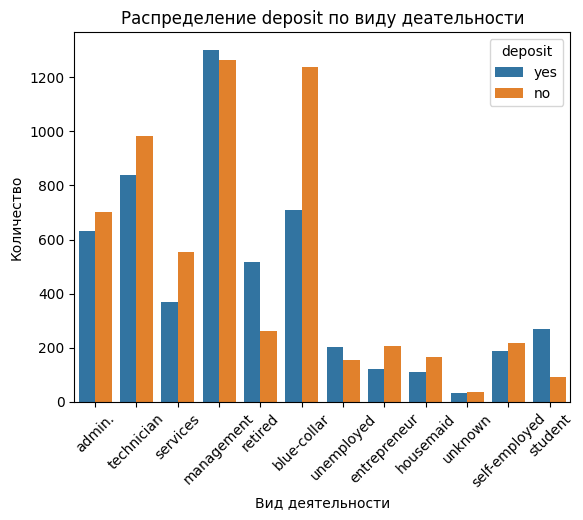

In [76]:
sns.countplot(data=df, x='job', hue='deposit')
plt.xticks(
    df['job'].unique(),
    rotation = 45)
plt.title('Распределение deposit по виду деательности')
plt.xlabel('Вид деятельности')
plt.ylabel('Количество')
plt.legend(title='deposit')
plt.show()

Ключевые различия в распределении сконцентрированы в группах “services”, “retired”, “blue-collar” и “student”. При этом если для пенсионеров и студентов причины были описаны выше, то низкая конверсия среди работников сервиса и разнорабочих, по-видимому, напрямую связана с невысоким уровнем их дохода, что снижает потенциальную возможность открытия депозита.

In [86]:
bins = [0,100,200,500,1000,5000]
labels =['0-100','100-200','200-500','500-1000','1000+']
df['duration_group'] = pd.cut(df['duration'], bins=bins, labels=labels, right=False)

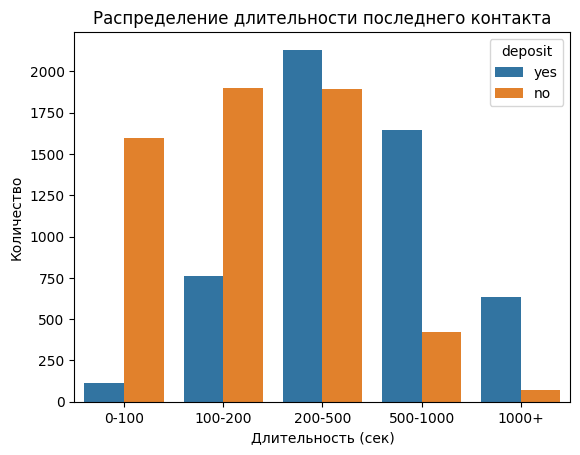

In [ ]:
sns.countplot(data=df, x='duration_group', hue='deposit')
plt.title('Распределение длительности последнего контакта')
plt.xlabel('Длительность (сек)')
plt.ylabel('Количество')
plt.show()

Наблюдается прямая корреляция между продолжительностью контакта с клиентом и вероятностью оформления депозита: чем длительнее взаимодействие, тем выше конверсия.

In [122]:
bins = [0,1,3,20]
labels =['1','2-3','4+']
df['campaign_group'] = pd.cut(df['campaign'], bins=bins, labels=labels)

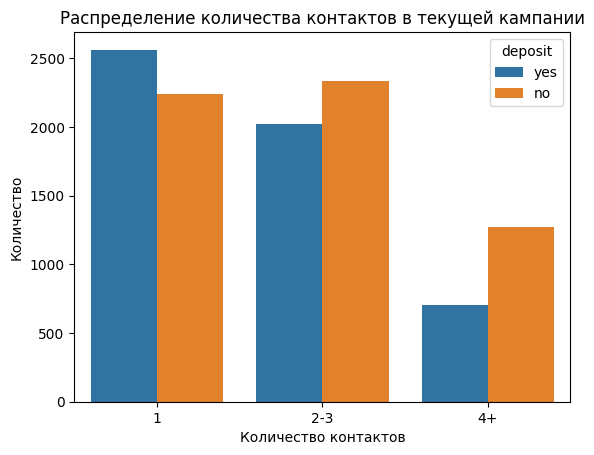

In [123]:
sns.countplot(data=df, x='campaign_group', hue='deposit')
plt.title('Распределение количества контактов в текущей кампании')
plt.xlabel('Количество контактов')
plt.ylabel('Количество')
plt.show()

Распределение демонстрирует, что по мере увеличения частоты взаимодействий с клиентом, его готовность оформить депозит заметно снижается. Вероятно, здесь мы сталкиваемся с эффектом "назойливости" или избыточной коммуникацией.

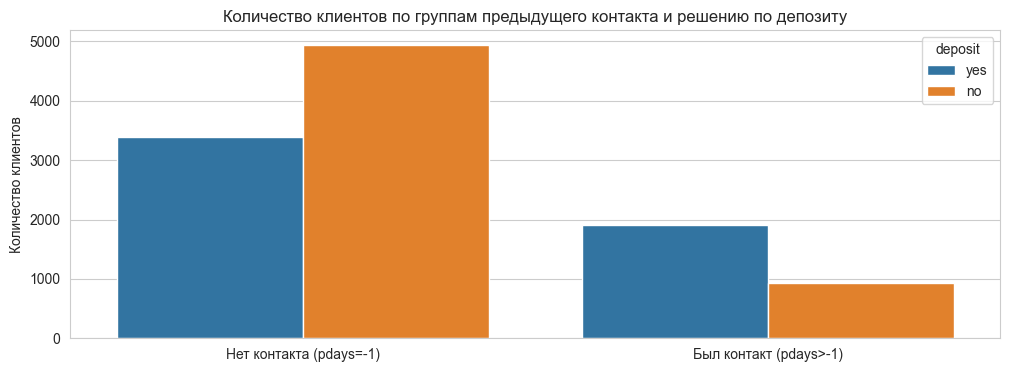

In [128]:
# Создаём индикатор наличия предыдущего контакта
df['had_contact'] = df['pdays'] != -1
# Для подписей на графике создадим категориальную переменную
df['contact_group'] = df['had_contact'].map({False: 'Нет контакта (pdays=-1)', 
                                              True: 'Был контакт (pdays>-1)'})
sns.countplot(data=df, x='contact_group', hue='deposit', order=['Нет контакта (pdays=-1)', 'Был контакт (pdays>-1)'])
plt.title('Количество клиентов по группам предыдущего контакта и решению по депозиту')
plt.xlabel('')
plt.ylabel('Количество клиентов')
plt.show()


В сегменте клиентов, с которыми был установлен контакт, наблюдается существенно более высокая склонность к открытию депозита (конверсия), чем в сегменте “без контакта».»